# 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Carregamento dos Dados

In [2]:
df_pedidos = pd.read_csv('/content/pedidos.csv')

# 3. EDA

In [3]:
df_pedidos.head()

,ID_Pedido,Data,Cliente_ID,Item,Quantidade,Preco_Unitario
0,1,2023-11-16,222,Torta de Limao,23.0,12.93
1,2,2024-05-25,232,Esfiha,NaN,5.87
2,3,2024-12-20,276,Wrap de Frango,7.0,25.98
3,4,2024-10-17,198,Batata Frita,NaN,11.62
4,5,2023-07-06,385,Esfiha,17.0,6.94


In [4]:
df_pedidos.tail()

,ID_Pedido,Data,Cliente_ID,Item,Quantidade,Preco_Unitario
445,446,2024-02-27,360,Salada Caesar,30.0,27.35
446,447,2025-05-29,228,Salada Caesar,24.0,29.40
447,448,2025-08-23,243,Agua Mineral,26.0,4.54
448,449,2024-08-30,191,Pizza Calabresa,9.0,45.85
449,450,2025-09-29,122,Yakisoba,8.0,31.72


In [5]:
df_pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID_Pedido       450 non-null    int64  
 1   Data            450 non-null    object 
 2   Cliente_ID      450 non-null    int64  
 3   Item            450 non-null    object 
 4   Quantidade      431 non-null    float64
 5   Preco_Unitario  430 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 21.2+ KB


In [6]:
df_pedidos.describe()

,ID_Pedido,Cliente_ID,Quantidade,Preco_Unitario
count,450.000000,450.000000,431.000000,430.000000
mean,225.500000,245.864444,15.902552,17.856581
std,130.048068,88.360604,9.087931,11.601652
min,1.000000,100.000000,1.000000,4.090000
25%,113.250000,169.000000,8.000000,8.920000
50%,225.500000,241.500000,16.000000,13.095000
75%,337.750000,325.750000,24.000000,27.402500
max,450.000000,399.000000,30.000000,46.070000


* Foram identificados valores nulos nas colunas `Quantidade` (19 registros) e `Preco_Unitario` (20 registros).
- A coluna `Data` está no tipo `object`.


# 4. Feature Engineering

In [7]:
df_pedidos['Receita_Item'] = df_pedidos['Quantidade'] * df_pedidos['Preco_Unitario']
df_pedidos.head()

,ID_Pedido,Data,Cliente_ID,Item,Quantidade,Preco_Unitario,Receita_Item
0,1,2023-11-16,222,Torta de Limao,23.0,12.93,297.39
1,2,2024-05-25,232,Esfiha,NaN,5.87,NaN
2,3,2024-12-20,276,Wrap de Frango,7.0,25.98,181.86
3,4,2024-10-17,198,Batata Frita,NaN,11.62,NaN
4,5,2023-07-06,385,Esfiha,17.0,6.94,117.98


- Foi criada a coluna `Receita_Item` a partir da multiplicação de `Quantidade` e `Preco_Unitario`.

# 5. Tratamento de Dados

In [8]:
# Identificar nulos
df_pedidos.isna().sum()

,0
ID_Pedido,0
Data,0
Cliente_ID,0
Item,0
Quantidade,19
Preco_Unitario,20
Receita_Item,38


In [9]:
# Preencher Quantidade com a média
df_pedidos_preenchido = df_pedidos.copy()
media_qtd = df_pedidos_preenchido['Quantidade'].mean()
df_pedidos_preenchido['Quantidade'] = df_pedidos_preenchido['Quantidade'].fillna(media_qtd)

In [10]:
# Remover nulos de Preco_Unitario
df_pedidos_limpo = df_pedidos_preenchido.dropna(subset=['Preco_Unitario'])

In [11]:
# Corrigindo valores de 'Receita_Item'
df_pedidos_limpo['Receita_Item'] = (df_pedidos_limpo['Quantidade'] * df_pedidos_limpo['Preco_Unitario'])

/tmp/ipykernel_5955/2706690966.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pedidos_limpo['Receita_Item'] = (df_pedidos_limpo['Quantidade'] * df_pedidos_limpo['Preco_Unitario'])


In [12]:
df_pedidos_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 430 entries, 0 to 449
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID_Pedido       430 non-null    int64  
 1   Data            430 non-null    object 
 2   Cliente_ID      430 non-null    int64  
 3   Item            430 non-null    object 
 4   Quantidade      430 non-null    float64
 5   Preco_Unitario  430 non-null    float64
 6   Receita_Item    430 non-null    float64
dtypes: float64(3), int64(2), object(2)
memory usage: 26.9+ KB


In [13]:
df_pedidos_limpo.isna().sum()

,0
ID_Pedido,0
Data,0
Cliente_ID,0
Item,0
Quantidade,0
Preco_Unitario,0
Receita_Item,0


* A coluna `Receita_Item` apresentou 38 valores nulos, por causa dos dados ausentes em `Quantidade` e `Preco_Unitario`.

* Os valores nulos em `Quantidade` foram preenchidos com a média da coluna

* As linhas com valores nulos em `Preco_Unitario` foram removidas

* A coluna `Receita_Item` foi recalculada para garantir que não haja mais valores nulos.

# 6. Agregações

In [14]:
# Análise por item
pedidos_por_itens = df_pedidos_limpo.groupby('Item').agg(
    Quantidade_Total = ('Quantidade', 'sum'),
    Receita_Total = ('Receita_Item', 'sum')
).reset_index()
print(pedidos_por_itens)

                   Item  Quantidade_Total  Receita_Total
0            Acai 300ml        402.902552    6502.133503
1          Agua Mineral        327.902552    1469.399327
2          Batata Frita        323.902552    3970.357657
3               Brownie        465.902552    4603.498237
4         Cafe Expresso        392.000000    2657.710000
5              Empanada        321.902552    2893.260928
6                Esfiha        364.707657    2379.656798
7            Hamburguer        510.805104   11562.230858
8                Pastel        238.000000    2215.460000
9       Pizza Calabresa        372.805104   15903.647958
10      Pizza Mussarela        349.000000   14148.690000
11    Refrigerante Lata        343.000000    2606.870000
12        Salada Caesar        352.000000    9927.960000
13  Smoothie de Morango        325.902552    4745.437517
14      Sorvete 2 bolas        284.000000    3137.760000
15      Suco de Laranja        263.805104    2412.527471
16        Sushi 8 pecas        

In [15]:
itens_mais_pedidos = pedidos_por_itens.sort_values(by='Quantidade_Total', ascending=False).iloc[0:5]
print(itens_mais_pedidos)

             Item  Quantidade_Total  Receita_Total
7      Hamburguer        510.805104   11562.230858
3         Brownie        465.902552    4603.498237
0      Acai 300ml        402.902552    6502.133503
4   Cafe Expresso        392.000000    2657.710000
16  Sushi 8 pecas        378.902552   12085.156473


In [16]:
itens_maior_receita = pedidos_por_itens.sort_values(by='Receita_Total', ascending=False).iloc[0:5]
print(itens_maior_receita)

               Item  Quantidade_Total  Receita_Total
9   Pizza Calabresa        372.805104   15903.647958
10  Pizza Mussarela        349.000000   14148.690000
16    Sushi 8 pecas        378.902552   12085.156473
7        Hamburguer        510.805104   11562.230858
12    Salada Caesar        352.000000    9927.960000


* O item mais vendido foi `Hamburguer`, com um total de 510.805104 unidades vendidas.

* O item com maior geração de receita foi `Pizza Calabresa`, com 15903.647958 em receita total.

* O item mais vendido e o 4º com maior receita, enquanto o com maior receita não está nos 5 mais vendidos. Indicando diferenças de preço entre os produtos.

# 7. Análise Temporal

In [17]:
# Análise por período
df_pedidos_limpo['Data'] = pd.to_datetime(df_pedidos_limpo['Data'])
df_pedidos_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 430 entries, 0 to 449
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       430 non-null    int64         
 1   Data            430 non-null    datetime64[ns]
 2   Cliente_ID      430 non-null    int64         
 3   Item            430 non-null    object        
 4   Quantidade      430 non-null    float64       
 5   Preco_Unitario  430 non-null    float64       
 6   Receita_Item    430 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 26.9+ KB


/tmp/ipykernel_5955/3344730495.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pedidos_limpo['Data'] = pd.to_datetime(df_pedidos_limpo['Data'])


In [18]:
df_pedidos_limpo['Mes_Pedido'] = df_pedidos_limpo['Data'].dt.month
df_pedidos_limpo.head()

/tmp/ipykernel_5955/114902095.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pedidos_limpo['Mes_Pedido'] = df_pedidos_limpo['Data'].dt.month


,ID_Pedido,Data,Cliente_ID,Item,Quantidade,Preco_Unitario,Receita_Item,Mes_Pedido
0,1,2023-11-16,222,Torta de Limao,23.000000,12.93,297.390000,11
1,2,2024-05-25,232,Esfiha,15.902552,5.87,93.347981,5
2,3,2024-12-20,276,Wrap de Frango,7.000000,25.98,181.860000,12
3,4,2024-10-17,198,Batata Frita,15.902552,11.62,184.787657,10
4,5,2023-07-06,385,Esfiha,17.000000,6.94,117.980000,7


In [19]:
pedidos_por_mes = df_pedidos_limpo.groupby('Mes_Pedido')['Receita_Item'].sum().reset_index()
print(pedidos_por_mes)

    Mes_Pedido  Receita_Item
0            1  10102.202668
1            2  16011.540000
2            3   7983.080000
3            4   8549.233503
4            5  12041.371067
5            6   9261.508863
6            7  10592.674084
7            8  12943.373503
8            9  14680.497517
9           10   5405.276984
10          11   6901.480000
11          12   8180.353341


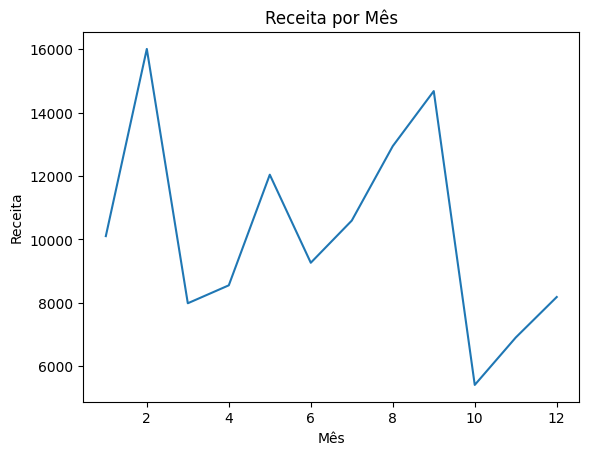

In [20]:
# gráfico
plt.plot(pedidos_por_mes['Mes_Pedido'], pedidos_por_mes['Receita_Item'])
plt.title('Receita por Mês')
plt.xlabel('Mês')
plt.ylabel('Receita')
plt.show()

* A receita apresenta variações ao longo dos meses, sem um crescimento contínuo.

* Um pico de vendas nos meses 2 e 9.

* Há uma queda no mês 3 e uma outra muito maior no mês 10, seguida de leve recuperação.

# 8. Merge

In [21]:
df_cardapio = pd.read_csv('/content/cardapio.csv')

In [22]:
# Integre com cardápio
df_merge = pd.merge(df_pedidos_limpo, df_cardapio, on='Item', how='left')
df_merge.head()

,ID_Pedido,Data,Cliente_ID,Item,Quantidade,Preco_Unitario,Receita_Item,Mes_Pedido,Categoria,Preco_Base
0,1,2023-11-16,222,Torta de Limao,23.000000,12.93,297.390000,11,Doces,12.9
1,2,2024-05-25,232,Esfiha,15.902552,5.87,93.347981,5,Salgados,6.5
2,3,2024-12-20,276,Wrap de Frango,7.000000,25.98,181.860000,12,Saudaveis,26.5
3,4,2024-10-17,198,Batata Frita,15.902552,11.62,184.787657,10,Salgados,12.5
4,5,2023-07-06,385,Esfiha,17.000000,6.94,117.980000,7,Salgados,6.5


In [23]:
receita_por_categoria = df_merge.groupby('Categoria').agg(Receita_Total = ('Receita_Item', 'sum')).reset_index()
print(receita_por_categoria)

   Categoria  Receita_Total
0    Bebidas    9146.506798
1      Doces   22293.944060
2   Oriental   21599.796473
3   Salgados   53073.304200
4  Saudaveis   16539.040000


In [24]:
categoria_maior_receita = receita_por_categoria.sort_values(by='Receita_Total', ascending=False).iloc[0]
categoria_maior_receita.head()

,3
Categoria,Salgados
Receita_Total,53073.3042


* A categoria com maior geração de receita foi `Salgados`.

# 9. Filtros

In [25]:
# Aplique filtros específicos
df_query = df_merge.query('Categoria == "Salgados" and Quantidade > 10')
print(df_query)

     ID_Pedido       Data  Cliente_ID             Item  Quantidade  \
1            2 2024-05-25         232           Esfiha   15.902552   
3            4 2024-10-17         198     Batata Frita   15.902552   
4            5 2023-07-06         385           Esfiha   17.000000   
5            6 2023-02-04         260         Empanada   16.000000   
14          15 2023-02-03         103     Batata Frita   14.000000   
..         ...        ...         ...              ...         ...   
404        423 2023-02-05         252  Pizza Calabresa   16.000000   
409        428 2023-07-11         278           Pastel   18.000000   
415        434 2024-07-17         249           Esfiha   26.000000   
422        442 2023-01-02         261           Esfiha   15.902552   
424        444 2024-04-16         133           Esfiha   27.000000   

     Preco_Unitario  Receita_Item  Mes_Pedido Categoria  Preco_Base  
1              5.87     93.347981           5  Salgados         6.5  
3             11.62

# 10. KPIs

In [26]:
# Calcule indicadores
receita_total_gerada = df_merge['Receita_Item'].sum()
print(receita_total_gerada)

122652.59153132251


In [27]:
total_itens_vendidos = df_merge['Quantidade'].sum()
print(total_itens_vendidos)

6833.245939675175


In [28]:
total_pedidos = df_merge['ID_Pedido'].nunique()

ticket_medio = receita_total_gerada / total_pedidos
print(ticket_medio)

285.23858495656395


- Receita Total: 122652.59153132251

- Total de Itens Vendidos: 6833.245939675175

- Ticket Médio: 285.23858495656395

# 11. Desafio Extra

In [29]:
percentis_preco = np.percentile(df_merge['Preco_Unitario'], [25, 50, 75])
print(percentis_preco)

[ 8.92   13.095  27.4025]


In [30]:
percentis_quantidade = np.percentile(df_merge['Quantidade'], [25, 50, 75])
print(percentis_quantidade)

[ 8. 16. 24.]
